# Probability Mass Function (PMF)

A probability distribution function is a mathematical function that describes the probability of getting different values of a random variable. It comes in two types, depending on whether the random variable is discrete or continuous.

* **Probability Mass Function (PMF)**, used for discrete random variables.
* **Probability Density Function (PDF)**, used for continuous random variables.

This notebook covers PMF. We'll cover PDF separately, since continuous variables need a different way of thinking about probability.

## What is a PMF?

PMF stands for Probability Mass Function. It's a function that assigns a probability to each possible value a discrete random variable can take.

For a function to be a valid PMF, it must follow two rules:

1. **Every probability must be non negative.** You can't have a negative chance of something happening.
2. **All the probabilities together must add up to exactly 1.** Something has to happen, so the total chance across all possible outcomes must be 100%.

For a single fair die, the PMF looks like this:

$$f(x) = \begin{cases} \frac{1}{6} & \text{if } x \in \{1, 2, 3, 4, 5, 6\} \\ 0 & \text{otherwise} \end{cases}$$

This just says, each face of the die has a 1/6 chance, and any number that isn't on the die (like 7 or 0) has zero chance.

## Illustrating PMF with a Die

Let's write this function in code and check that it actually satisfies both PMF rules, non negative probabilities, and they sum to 1.

In [2]:
#Let's first illustrate it through hard coding then we will perform and an experiment for better illustration
def die_pmf(x):
    if x in [1, 2, 3, 4, 5, 6]:
        return 1 / 6
    else:
        return 0

# check a few values
for x in [1, 3, 6, 7, 0]:
    print(f"P(X = {x}) = {die_pmf(x)}")

# check the two PMF rules
probabilities = [die_pmf(x) for x in [1, 2, 3, 4, 5, 6]]
print("\nAll non negative:", all(p >= 0 for p in probabilities))
print("Sum of probabilities:", sum(probabilities))

P(X = 1) = 0.16666666666666666
P(X = 3) = 0.16666666666666666
P(X = 6) = 0.16666666666666666
P(X = 7) = 0
P(X = 0) = 0

All non negative: True
Sum of probabilities: 1.0


In [3]:
import random

random.seed(42)

rolls = [random.randint(1, 6) for _ in range(2000)]
rolls[:10]

[6, 1, 1, 6, 3, 2, 2, 2, 6, 1]

## Turning Simulated Rolls Into a PMF

Now that we have 2000 simulated rolls, let's count how often each face appeared, and convert those counts into probabilities. If our die is fair, each face should show up close to 1/6 of the time.

In [5]:
import pandas as pd

roll_counts = pd.Series(rolls).value_counts().sort_index()
roll_probs = roll_counts / len(rolls)

roll_counts

1    329
2    314
3    335
4    340
5    328
6    354
Name: count, dtype: int64

In [6]:
roll_probs

1    0.1645
2    0.1570
3    0.1675
4    0.1700
5    0.1640
6    0.1770
Name: count, dtype: float64

these experimental probabilities are nearly equal to the theoritical probabilities 0.1666

## Visualizing the PMF

Since a die roll is discrete, we use a bar chart, not a smooth curve. Each bar represents one possible outcome, and its height is the probability of that outcome.

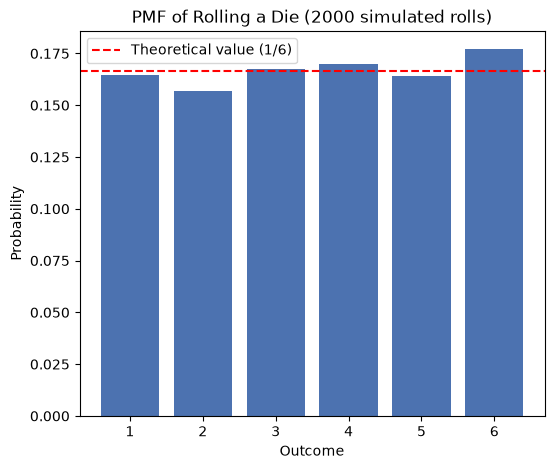

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.bar(roll_probs.index, roll_probs.values, color='#4C72B0')
plt.axhline(y=1/6, color='red', linestyle='--', label='Theoretical value (1/6)')
plt.title('PMF of Rolling a Die (2000 simulated rolls)')
plt.xlabel('Outcome')
plt.ylabel('Probability')
plt.legend()
plt.show()

## Checking the Two PMF Rules on Real Data

Even though this came from random simulation rather than a clean formula, it should still follow the two rules that any valid PMF must satisfy.

In [8]:
print("All probabilities non negative:", all(p >= 0 for p in roll_probs))
print("Sum of all probabilities:", roll_probs.sum())

All probabilities non negative: True
Sum of all probabilities: 1.0


## Applying PMF to Real Data

Let's move from a simulated die to a real dataset. In the tips dataset, the `size` column (number of people at a table) is a discrete random variable, it only takes whole number values, just like a die roll.

Let's find its PMF: for each possible table size, what's the probability of seeing that size in this dataset?

In [10]:
import seaborn as sns

df = sns.load_dataset("tips")

size_counts = df['size'].value_counts().sort_index()
size_probs = size_counts / len(df)
print(size_counts)
size_probs

size
1      4
2    156
3     38
4     37
5      5
6      4
Name: count, dtype: int64


size
1    0.016393
2    0.639344
3    0.155738
4    0.151639
5    0.020492
6    0.016393
Name: count, dtype: float64

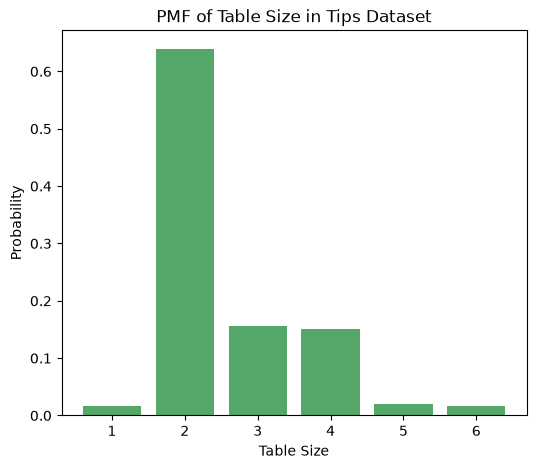

In [11]:
plt.figure(figsize=(6, 5))
plt.bar(size_probs.index, size_probs.values, color='#55A868')
plt.title('PMF of Table Size in Tips Dataset')
plt.xlabel('Table Size')
plt.ylabel('Probability')
plt.show()

Looking at this chart, a table size of 2 is by far the most common, happening roughly 64% of the time. Table sizes of 3 and 4 are both moderately common, each around 15%. Tables of 1, 5, or 6 people are rare, each under 2%.

This makes sense in the real world, most people go out to eat in pairs. Larger groups happen, but far less often. Notice how different this looks from the die roll, where every outcome had an equal 1/6 chance. Here, the probabilities are uneven, which is normal and expected for real data. A PMF doesn't require equal probabilities, it just requires that every probability is non negative and that they all add up to 1.

## Checking the Rules Again, This Time on Real Data

Just like the die, this real distribution of table sizes should still follow the two PMF rules.

In [12]:
print("All probabilities non negative:", all(p >= 0 for p in size_probs))
print("Sum of all probabilities:", size_probs.sum())

All probabilities non negative: True
Sum of all probabilities: 1.0


## Summary

A PMF takes a discrete random variable and tells you the probability of each possible value it can take. We saw this in two settings:

* A simulated die roll, where the probabilities matched the theoretical 1/6 fairly closely after 2000 rolls.
* Real restaurant data, where most tables have 2 people, and larger tables become rarer, a pattern that comes from actual human behavior, not a clean mathematical formula.

In both cases, the two defining rules of a PMF held true: every probability was non negative, and they all added up to exactly 1.

This is the discrete half of probability distributions. Next, we'll look at the continuous half, the Probability Density Function (PDF), which needs a slightly different way of thinking since continuous variables can't be counted the same way.

## Wait, Where's the Function in the Real Data Example?

With the die, we had a clean formula: $f(x) = 1/6$ for any valid face. But with table size, there's no such clean equation. So is it still a PMF?

Yes, but it's a different kind. The die's PMF is **theoretical**, based on the known mechanics of a fair die, before we even roll it. The table size PMF is **empirical**, it comes from counting what actually happened in real data.

Both are still valid PMFs, because the underlying definition doesn't require a neat algebraic formula. It just requires a function that maps each possible value to a probability, following the two rules (non negative, sums to 1). For real data, that function is simply:

$$f(x) = \frac{\text{count of } x \text{ in the data}}{\text{total number of observations}}$$

This is still technically $y = f(x)$. It's just that the "formula" is "go count the actual occurrences," rather than a clean mathematical expression like 1/6. In real world data science, most PMFs you'll encounter are empirical like this, since real processes (like how many people come to a restaurant) are rarely as clean and symmetric as a fair die.